# **1. Perkenalan Dataset**

Notebook eksperimen ini menggunakan **Banknote Authentication Dataset** dari
UCI Machine Learning Repository (dataset ID 267, DOI 10.24432/C55P57).
Dataset berisi 1.372 sampel, 4 fitur numerik hasil transformasi wavelet citra,
dan target biner yang membedakan banknote autentik dan palsu. Dataset ini
berbeda dari seluruh dataset yang dipakai pada latihan modul.

Tahapan eksperimen dilakukan manual mengikuti
struktur template: import library, data loading, EDA, dan preprocessing.
Dataset mentah disimpan pada `../banknote_raw.csv`, sedangkan hasil
preprocessing disimpan sebagai `banknote_preprocessing.csv`.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
print("Library berhasil dimuat.")

Library berhasil dimuat.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
RAW_DATA_PATH = Path("../banknote_raw.csv")

df_raw = pd.read_csv(RAW_DATA_PATH)
print(f"Ukuran dataset: {df_raw.shape}")
display(df_raw.head())

print("\nTipe data:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nDistribusi kelas:")
display(df_raw["target"].value_counts().sort_index().to_frame("jumlah"))

Ukuran dataset: (1372, 5)


,variance,skewness,curtosis,entropy,target
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0



Tipe data:


,dtype
variance,float64
skewness,float64
curtosis,float64
entropy,float64
target,int64



Distribusi kelas:


,jumlah
target,
0,762
1,610


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

,count,mean,std,min,25%,50%,75%,max
variance,1372.0,0.433735,2.842763,-7.0421,-1.773000,0.49618,2.821475,6.8248
skewness,1372.0,1.922353,5.869047,-13.7731,-1.708200,2.31965,6.814625,12.9516
curtosis,1372.0,1.397627,4.310030,-5.2861,-1.574975,0.61663,3.179250,17.9274
entropy,1372.0,-1.191657,2.101013,-8.5482,-2.413450,-0.58665,0.394810,2.4495
target,1372.0,0.444606,0.497103,0.0000,0.000000,0.00000,1.000000,1.0000


,missing_value,unique_value
variance,0,1338
skewness,0,1256
curtosis,0,1270
entropy,0,1156
target,0,2


Jumlah baris duplikat: 24


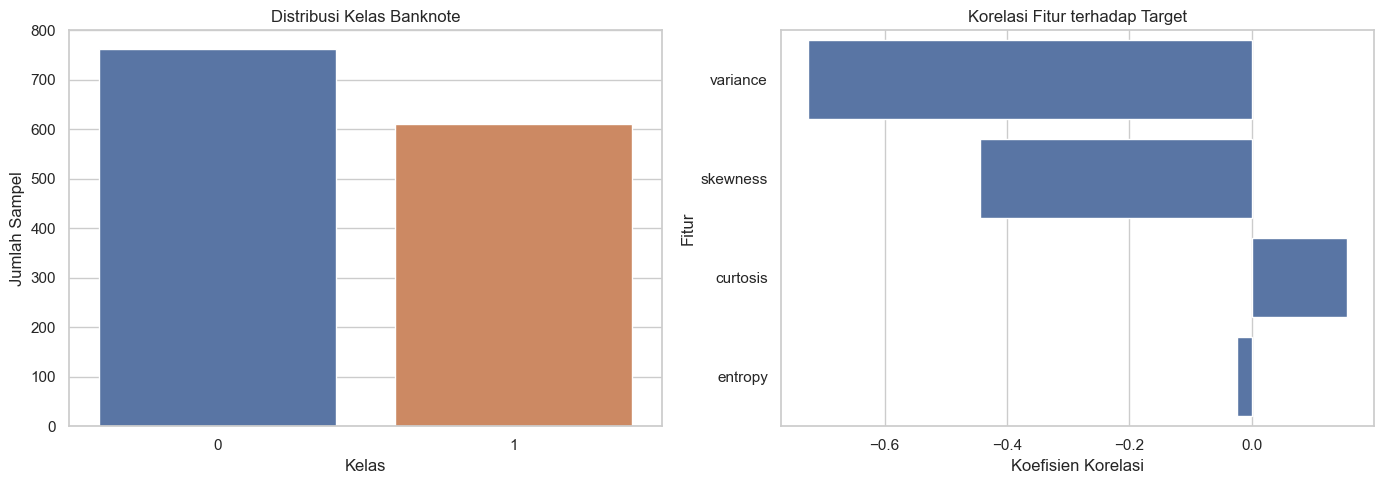

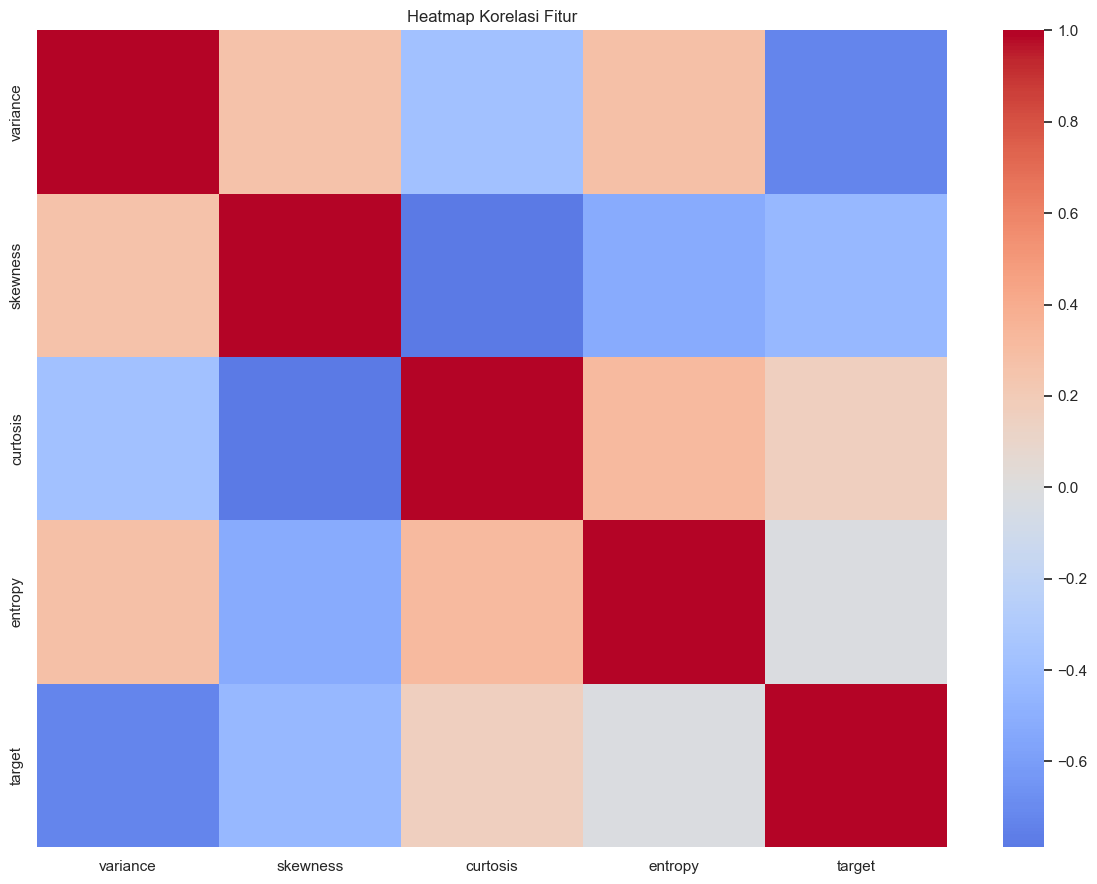

In [3]:
# Statistik deskriptif
display(df_raw.describe().T)

# Pemeriksaan kualitas data
quality_summary = pd.DataFrame({
    "missing_value": df_raw.isna().sum(),
    "unique_value": df_raw.nunique(),
})
display(quality_summary)
print(f"Jumlah baris duplikat: {df_raw.duplicated().sum()}")

# Distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df_raw, x="target", hue="target", legend=False, ax=axes[0])
axes[0].set_title("Distribusi Kelas Banknote")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah Sampel")

# Korelasi fitur dengan target
correlations = (
    df_raw.corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)
sns.barplot(x=correlations.values, y=correlations.index, ax=axes[1])
axes[1].set_title("Korelasi Fitur terhadap Target")
axes[1].set_xlabel("Koefisien Korelasi")
axes[1].set_ylabel("Fitur")
plt.tight_layout()
plt.show()

# Heatmap korelasi
plt.figure(figsize=(12, 9))
sns.heatmap(df_raw.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Heatmap Korelasi Fitur")
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
def preprocess_banknote_data(dataframe):
    processed = dataframe.copy()
    processed = processed.drop_duplicates().reset_index(drop=True)

    feature_columns = [column for column in processed.columns if column != "target"]
    for column in feature_columns:
        processed[column] = pd.to_numeric(processed[column], errors="coerce")
        processed[column] = processed[column].fillna(processed[column].median())

        lower_limit = processed[column].quantile(0.01)
        upper_limit = processed[column].quantile(0.99)
        processed[column] = processed[column].clip(lower_limit, upper_limit)

    processed["target"] = pd.to_numeric(
        processed["target"], errors="raise"
    ).astype(int)
    return processed


df_processed = preprocess_banknote_data(df_raw)
OUTPUT_PATH = Path("banknote_preprocessing.csv")
df_processed.to_csv(OUTPUT_PATH, index=False)

print(f"Data hasil preprocessing: {df_processed.shape}")
print(f"Missing value tersisa: {df_processed.isna().sum().sum()}")
print(f"Duplikat tersisa: {df_processed.duplicated().sum()}")
print(f"File tersimpan di: {OUTPUT_PATH.resolve()}")
display(df_processed.head())

Data hasil preprocessing: (1348, 5)
Missing value tersisa: 0
Duplikat tersisa: 0
File tersimpan di: /Users/mac/Documents/help me finish advaced quiz/quiz4-msml/Eksperimen_SML_adiab/preprocessing/banknote_preprocessing.csv


,variance,skewness,curtosis,entropy,target
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


## **6. Kesimpulan**

Dataset telah dimuat, dianalisis, dibersihkan dari duplikasi, diimputasi bila
terdapat nilai kosong, dan dibatasi pada persentil 1-99 untuk mengurangi dampak
outlier ekstrem. Hasil akhir siap digunakan untuk pelatihan model.

In [5]:
assert df_processed.shape[1] == 5
assert df_processed.isna().sum().sum() == 0
assert set(df_processed["target"].unique()) == {0, 1}
print("VALIDASI BERHASIL: dataset siap dilatih.")

VALIDASI BERHASIL: dataset siap dilatih.
